# Variables

For the data imputation process we will focus on the following variables:
- PM2.5 (μg/m³): material particulado menor a 2.5 micrómetros.
- NO₂ (ppb): dióxido de nitrógeno.
- CO (ppm): monóxido de carbono.
- NO (ppb): monóxido de nitrógeno.
- NOx (ppb): suma de NO y NO₂.

And the following stations:
- NO y CE - Monterrey
- NE - San Nicolás de los Garza
- SE - Guadalupe
- NE2 - Apodaca
- SO - Santa Catarina
- NO2 - García

In [1]:
# Imports and setup
import os
import numpy as np
import pandas as pd


# Load dataset and isolate selected variables/stations

This section loads the unified dataset and isolates only the variables and stations listed above. It follows the same conventions as the other notebooks (parse_dates, replace -9999 with NaN).


In [2]:
# Define target pollutants from markdown (normalize names to match dataset columns)
pollutants_markdown = ["PM2.5", "NO₂", "CO", "NO", "NOx"]
normalize_map = {"NO₂": "NO2", "NOx": "NOX"}
pollutants = [normalize_map.get(p, p) for p in pollutants_markdown]

# Define target stations and corresponding station codes
stations_markdown = [
    "NO y CE - Monterrey",
    "NE - San Nicolás de los Garza",
    "SE - Guadalupe",
    "NE2 - Apodaca",
    "SO - Santa Catarina",
    "NO2 - García",
]

# Map station labels from markdown to station_code values used in the main dataset
station_codes_map = {
    "NO y CE - Monterrey": ["NO", "CE"],
    "NE - San Nicolás de los Garza": ["NE"],
    "SE - Guadalupe": ["SE"],
    "NE2 - Apodaca": ["NE2"],
    "SO - Santa Catarina": ["SO"],
    "NO2 - García": ["NO2"],
}

target_station_codes = sorted({code for name in stations_markdown for code in station_codes_map.get(name, [])})

# Load dataset (same settings as in exploration notebook)
data_path = os.path.join("..", "data", "processed", "main_dataframe.csv")
df = pd.read_csv(
    data_path,
    parse_dates=["date"],
    engine="pyarrow"
)

# Treat sentinel missing values
df.replace(-9999, np.nan, inplace=True)

# Validate and select pollutant columns that exist
available_pollutants = [c for c in pollutants if c in df.columns]
missing_pollutants = [c for c in pollutants if c not in df.columns]
if missing_pollutants:
    print(f"Warning: the following pollutant columns were not found and will be skipped: {missing_pollutants}")

# Filter by station codes and keep only the relevant columns
keep_cols = ["date", "station_code"] + available_pollutants
subset = df[df["station_code"].astype(str).isin(target_station_codes)][keep_cols].copy()

# Sort by date for readability
if "date" in subset.columns:
    subset.sort_values("date", inplace=True)

# Save isolated subset
output_dir = os.path.join("..", "data", "processed")
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "imputation_subset.csv")
subset.to_csv(output_file, index=False)

print(f"Saved isolated subset to: {output_file}")
print("Station codes included:", target_station_codes)
print("Columns:", keep_cols)
print("Rows:", len(subset))

# Quick preview
subset.head()


Saved isolated subset to: ..\data\processed\imputation_subset.csv
Station codes included: ['CE', 'NE', 'NE2', 'NO', 'NO2', 'SE', 'SO']
Columns: ['date', 'station_code', 'PM2.5', 'NO2', 'CO', 'NO', 'NOX']
Rows: 375587


,date,station_code,PM2.5,NO2,CO,NO,NOX
0,2020-01-01,SE,54.23,NaN,NaN,NaN,NaN
35073,2020-01-01,CE,60.91,NaN,NaN,NaN,NaN
52609,2020-01-01,NO,70.81,NaN,NaN,NaN,NaN
70146,2020-01-01,SO,59.26,NaN,NaN,NaN,NaN
87683,2020-01-01,NO2,86.93,NaN,NaN,NaN,NaN


In [8]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

DATA_IN = os.path.join("..","data","processed","imputation_subset.csv")
REPORTS = os.path.join("..","reports")
FIGS    = os.path.join(REPORTS, "figs")
os.makedirs(FIGS, exist_ok=True)

df = pd.read_csv(DATA_IN, parse_dates=["date"]).sort_values(["station_code","date"])
value_cols = [c for c in df.columns if c not in ["date","station_code"]]

# % faltantes por contaminante (global)
miss_pollutant = df[value_cols].isna().mean().sort_values(ascending=False)*100
miss_pollutant.to_csv(os.path.join(REPORTS,"missing_by_pollutant.csv"))
print("Missing % by pollutant:\n",miss_pollutant)



Missing % by pollutant:
 NOX      31.963300
PM2.5    18.338494
NO2      17.423127
NO       15.900710
CO       11.443687
dtype: float64


In [12]:
# % faltantes por estación y contaminante
miss_station_poll = (df.groupby("station_code")[value_cols]
                       .apply(lambda g: g.isna().mean()*100)  # %
                       .sort_index())
miss_station_poll.to_csv(os.path.join(REPORTS,"missing_by_station_pollutant.csv"))
print("Missing % by station and pollutant:\n",miss_station_poll.head(10))



Missing % by station and pollutant:
                   PM2.5        NO2         CO         NO        NOX
station_code                                                       
CE            13.266390   5.836764   2.934218   9.825437  21.299626
NE             7.653470  21.263158  11.336749  14.323242  37.034001
NE2           25.698688  25.143464  15.699061  24.962737  40.024594
NO            44.140771  23.183546  26.145763  19.308443  35.211268
NO2           14.377806  14.375943   2.675461  10.167123  24.992082
SE            13.446850  21.118522   8.629234  23.642833  37.268527
SO             9.763524  11.024357  12.688658   9.057457  27.902720


In [13]:
# % faltantes por estación (promedio sobre contaminantes)
miss_station = miss_station_poll.mean(axis=1).sort_values(ascending=False)
miss_station.to_csv(os.path.join(REPORTS,"missing_by_station.csv"))
miss_station.head(10)


station_code
NO     29.597958
NE2    26.305709
SE     20.821193
NE     18.322124
SO     14.087343
NO2    13.317683
CE     10.632487
dtype: float64

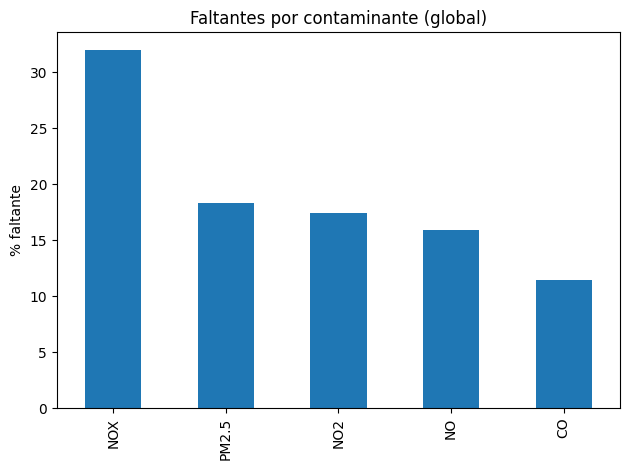

In [14]:
# Barras: % faltantes por contaminante (global)
plt.figure()
miss_pollutant.plot(kind="bar")
plt.ylabel("% faltante")
plt.title("Faltantes por contaminante (global)")
plt.tight_layout()
plt.savefig(os.path.join(FIGS,"bar_missing_by_pollutant.png"), dpi=150)
plt.show()


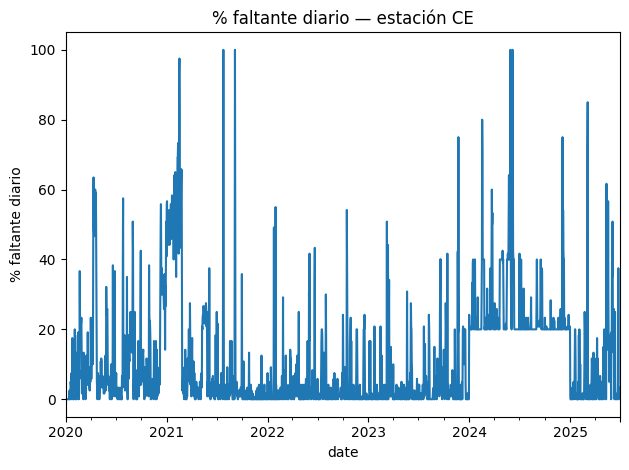

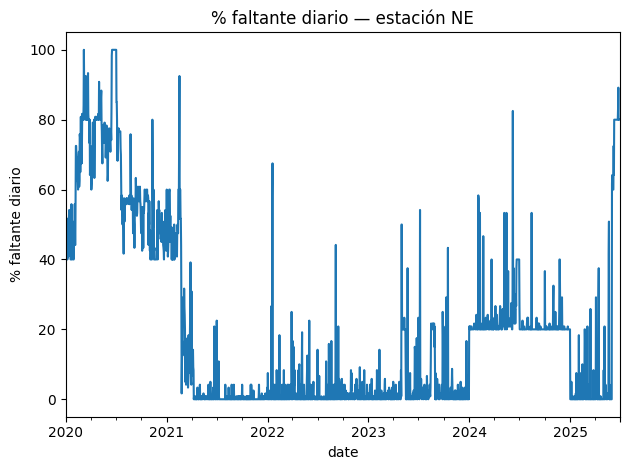

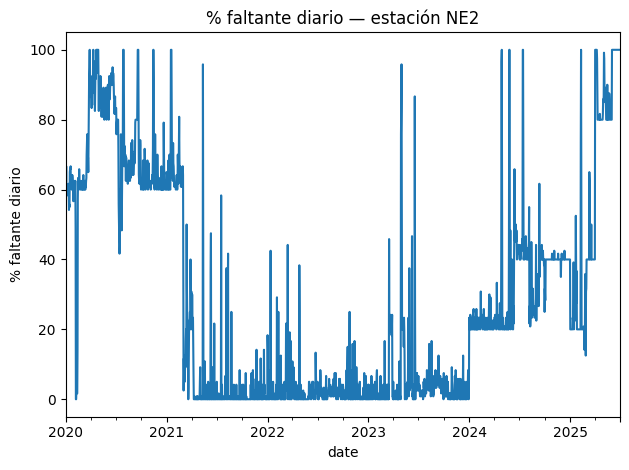

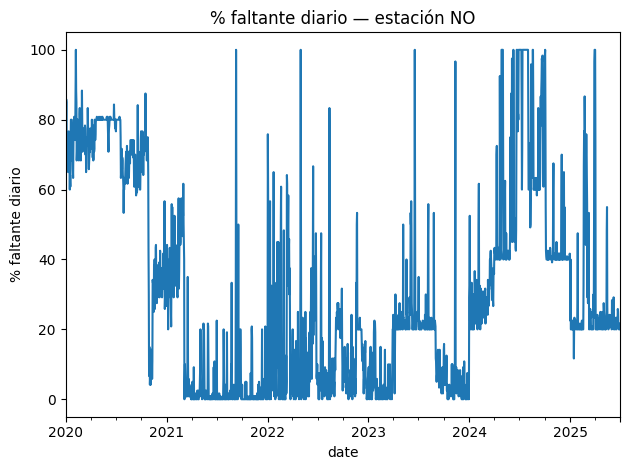

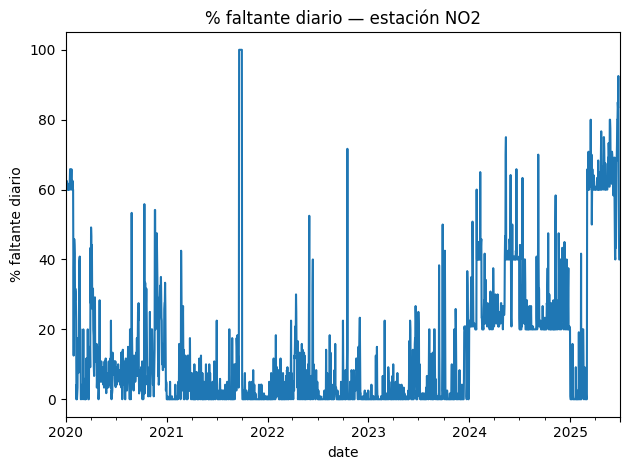

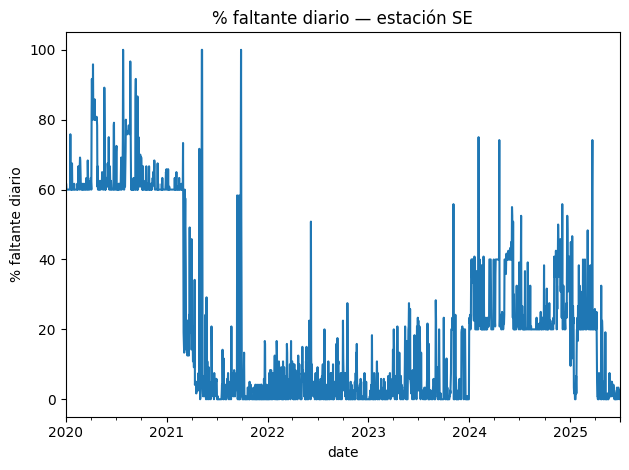

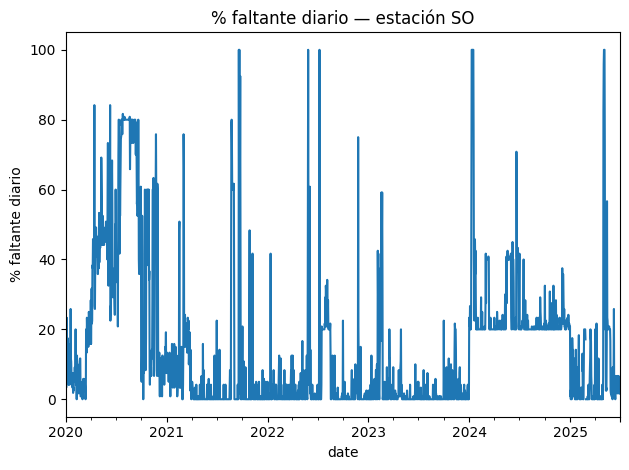

In [15]:
# Función: % faltante diario (promedio entre contaminantes) para una estación
def plot_daily_missing_rate(station_code, start=None, end=None):
    g = df[df["station_code"]==station_code].set_index("date")[value_cols]
    if start: g = g[g.index >= pd.to_datetime(start)]
    if end:   g = g[g.index <= pd.to_datetime(end)]
    daily = g.isna().mean(axis=1).resample("D").mean()*100  # % por día
    plt.figure()
    daily.plot()
    plt.ylabel("% faltante diario")
    ttl = f"% faltante diario — estación {station_code}"
    if start or end: ttl += f" ({start or ''} → {end or ''})"
    plt.title(ttl)
    plt.tight_layout()
    fname = f"daily_missing_{station_code}.png" if not (start or end) else f"daily_missing_{station_code}_{start}_{end}.png"
    plt.savefig(os.path.join(FIGS, fname), dpi=150)
    plt.show()

# Ejemplo: grafica para cada estación
for st in df["station_code"].dropna().unique():
    plot_daily_missing_rate(st)


In [16]:
def nan_runs(s: pd.Series):
    arr = s.isna().to_numpy()
    runs, count = [], 0
    for v in arr:
        if v: count += 1
        elif count>0: runs.append(count); count=0
    if count>0: runs.append(count)
    return runs

rows = []
for st, g in df.groupby("station_code"):
    g = g.sort_values("date")
    for c in value_cols:
        runs = nan_runs(g[c])
        if runs:
            runs = np.array(runs)
            rows.append({
                "station_code": st, "pollutant": c,
                "n_gaps": int(len(runs)),
                "mean_gap": float(runs.mean()),
                "p50_gap": float(np.percentile(runs,50)),
                "p90_gap": float(np.percentile(runs,90)),
                "max_gap": int(runs.max())
            })
gap_stats = pd.DataFrame(rows).sort_values(["station_code","pollutant"])
gap_stats.to_csv(os.path.join(REPORTS,"missing_gap_stats.csv"), index=False)
gap_stats.head(10)


,station_code,pollutant,n_gaps,mean_gap,p50_gap,p90_gap,max_gap
2,CE,CO,204,7.720588,1.0,16.0,503
3,CE,NO,1470,3.587755,2.0,8.0,66
1,CE,NO2,513,6.107212,2.0,14.8,294
4,CE,NOX,373,30.651475,2.0,12.8,8784
0,CE,PM2.5,1036,6.873552,1.0,13.0,432
7,NE,CO,268,22.705224,1.0,9.3,3957
8,NE,NO,837,9.185185,3.0,14.0,720
6,NE,NO2,216,52.837963,1.0,6.5,10059
9,NE,NOX,184,108.032609,1.0,6.0,10062
5,NE,PM2.5,841,4.884661,1.0,6.0,718


El siguiente bloque de codigo mide cual metodo es mejor para inputar los datos faltantes. Para eso simula faltantes (oculta datos que sí existen) y compara qué tan bien los recupera cada método.
* MTB (Mean Top–Bottom) — Promedia el valor anterior (ffill) y el siguiente (bfill) para rellenar cada hueco.

    * Implementado en fill_mtb(...).

    *Suele reducir errores grandes (bueno para RMSE).
* NN (Nearest Neighbour) — En cada bloque de NaN, asigna los valores del vecino temporal más cercano (mitad izquierda toma el previo, mitad derecha el siguiente; bordes usan ffill/bfill).

    * Implementado en fill_nn(...).

    * Tiende a tener buen MAE en huecos cortos.

* Iterative (MICE-like con scikit-learn) — Imputación multivariante: predice cada contaminante usando los demás, de forma iterativa (usa IterativeImputer).

    * Implementado en fill_iterative(frame, cols).

    * Aprovecha correlaciones entre contaminantes; útil si hay huecos largos.


In [4]:
import os
import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# =========================
# Configuración
# =========================
DATA_IN = os.path.join("..", "data", "processed", "imputation_subset.csv")
REPORTS_DIR = os.path.join("..", "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)
OUT_SUMMARY = os.path.join(REPORTS_DIR, "imputation_benchmark_summary.csv")
OUT_DETAIL  = os.path.join(REPORTS_DIR, "imputation_benchmark_detail.csv")

RANDOM_SEED = 42
PROP_HIDE = 0.10      # proporción a ocultar por columna para evaluar (10%)
BLOCK_LENS = [1, 2, 3, 4, 5, 6]  # longitudes de bloque (horas) similares al paper
N_REPEATS = 5

rng = np.random.default_rng(RANDOM_SEED)


# =========================
# Utilidades
# =========================
def make_block_mask_observed(y: pd.Series, prop=0.10, block_lens=(1,2,3,4,5)):
    """
    Crea una máscara booleana para ocultar ~prop de los valores OBSERVADOS (no NaN)
    en bloques continuos con longitudes tomadas de block_lens.
    Devuelve mask (bool array) con True = ocultar (solo donde había dato real).
    """
    y = y.to_numpy()
    n = len(y)
    obs = ~np.isnan(y)

    target = int(np.ceil(prop * obs.sum()))
    mask = np.zeros(n, dtype=bool)

    # índices candidatos donde hay observado y aún no oculto
    attempts = 0
    while mask.sum() < target and attempts < 10_000:
        L = rng.choice(block_lens)
        start = rng.integers(0, n)
        end = min(n, start + L)
        block_idx = np.arange(start, end)

        # requerimos que TODO el bloque sea observado y no esté ya elegido
        if block_idx.size == 0:
            attempts += 1
            continue
        if np.all(obs[block_idx] & (~mask[block_idx])):
            mask[block_idx] = True
        attempts += 1

    # asegura no exceder demasiado la meta
    if mask.sum() > target:
        # apaga algunos True al azar hasta acercarnos a target
        true_idx = np.where(mask)[0]
        rng.shuffle(true_idx)
        to_off = mask.sum() - target
        if to_off > 0:
            mask[true_idx[:to_off]] = False
    return mask


def fill_mtb(series: pd.Series) -> pd.Series:
    """Mean Top-Bottom: promedio entre ffill y bfill en posiciones NaN.
       En bordes (si falta uno de los vecinos) cae en el disponible (similar a NN)."""
    s = series.copy()
    na = s.isna()
    if na.all():
        return s
    prev = s.ffill()
    nxt  = s.bfill()
    mtb = (prev + nxt) / 2.0
    out = s.copy()
    out[na] = mtb[na]
    # si aún queda NaN (casos extremos), usa prev o next
    still = out.isna()
    out[still] = prev[still]
    still = out.isna()
    out[still] = nxt[still]
    return out


def fill_nn(series: pd.Series) -> pd.Series:
    """Nearest Neighbour en bloques: para cada bloque de NaN,
       la mitad más cercana al borde izquierdo toma el valor previo,
       la otra mitad toma el valor siguiente. Bordes extremos: ffill/bfill."""
    s = series.copy()
    vals = s.to_numpy().astype(float)
    n = len(vals)
    isn = np.isnan(vals)

    if isn.all():
        return s

    # posiciones con dato
    prev_val = pd.Series(vals).ffill().to_numpy()
    next_val = pd.Series(vals).bfill().to_numpy()

    i = 0
    while i < n:
        if not isn[i]:
            i += 1
            continue
        # inicio de bloque NaN
        start = i
        while i < n and isn[i]:
            i += 1
        end = i - 1  # bloque [start, end]
        left = start - 1
        right = end + 1

        # casos de borde
        if left < 0 and right >= n:
            # todo NaN: no hay nada que hacer, retorna igual
            return s
        elif left < 0:
            # solo vecino derecho
            vals[start:end+1] = next_val[start:end+1]
        elif right >= n:
            # solo vecino izquierdo
            vals[start:end+1] = prev_val[start:end+1]
        else:
            # ambos vecinos existen: partir el bloque por la mitad
            L = end - start + 1
            half = L // 2  # primera mitad hacia el izquierdo
            if half > 0:
                vals[start:start+half] = prev_val[start:start+half]
            vals[start+half:end+1] = next_val[start+half:end+1]

    return pd.Series(vals, index=s.index, name=s.name)


def fill_iterative(frame: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Imputación multivariante (MICE-like) por estación para todas las columnas en cols."""
    g = frame.copy()
    X = g[cols].to_numpy(dtype=float)
    if np.isnan(X).sum() == 0:
        return g
    imputer = IterativeImputer(
        random_state=RANDOM_SEED,
        max_iter=10,
        sample_posterior=True,
        tol=1e-3
    )
    X_imp = imputer.fit_transform(X)
    g[cols] = X_imp
    return g


def mae_rmse(y_true, y_pred):
    e = y_true - y_pred
    mae = np.mean(np.abs(e))
    rmse = np.sqrt(np.mean(e**2))
    return float(mae), float(rmse)


# =========================
# Carga de datos
# =========================
df = pd.read_csv(DATA_IN, parse_dates=["date"])
df = df.sort_values(["station_code", "date"]).reset_index(drop=True)
value_cols = [c for c in df.columns if c not in ["date", "station_code"]]

print("Columnas a imputar:", value_cols)
print("Estaciones:", df["station_code"].unique().tolist())

# =========================
# Benchmark
# =========================
rows_detail = []
rows_summary = []

methods = ("MTB", "NN", "Iterative")

for rep in range(N_REPEATS):
    print(f"\nRepetición {rep+1}/{N_REPEATS}")
    for st, g0 in df.groupby("station_code"):
        g0 = g0.sort_values("date").reset_index(drop=True)

        # Construye copia para enmascarar faltantes "de evaluación"
        g_masked = g0.copy()
        eval_masks = {}

        # Por columna: oculta ~PROP_HIDE de datos OBSERVADOS en bloques 1-6 horas
        for c in value_cols:
            m = make_block_mask_observed(g0[c], prop=PROP_HIDE, block_lens=BLOCK_LENS)
            eval_masks[c] = m
            # Oculta SOLO donde había un dato real
            g_masked.loc[m, c] = np.nan

        # =======================
        # Ejecuta cada método
        # =======================
        results = {}
        # 1) MTB (univariante por columna)
        g_mtb = g_masked.copy()
        for c in value_cols:
            g_mtb[c] = fill_mtb(g_mtb[c])

        # 2) NN (univariante por columna)
        g_nn = g_masked.copy()
        for c in value_cols:
            g_nn[c] = fill_nn(g_nn[c])

        # 3) Iterative (multivariante)
        g_iter = fill_iterative(g_masked, value_cols)

        outs = {"MTB": g_mtb, "NN": g_nn, "Iterative": g_iter}

        # =======================
        # Métricas por contaminante y global
        # =======================
        for name, g_out in outs.items():
            # Por contaminante
            for c in value_cols:
                m = eval_masks[c]
                if m.sum() == 0:
                    continue
                y_true = g0.loc[m, c].to_numpy(dtype=float)
                y_pred = g_out.loc[m, c].to_numpy(dtype=float)
                mae, rmse = mae_rmse(y_true, y_pred)
                rows_detail.append({
                    "repeat": rep,
                    "station_code": st,
                    "method": name,
                    "pollutant": c,
                    "MAE": mae,
                    "RMSE": rmse,
                    "n_eval": int(m.sum())
                })

            # Global (todas las columnas juntas)
            y_true_all, y_pred_all = [], []
            for c in value_cols:
                m = eval_masks[c]
                y_true_all.append(g0.loc[m, c].to_numpy(dtype=float))
                y_pred_all.append(g_out.loc[m, c].to_numpy(dtype=float))
            y_true_all = np.concatenate(y_true_all) if y_true_all else np.array([])
            y_pred_all = np.concatenate(y_pred_all) if y_pred_all else np.array([])
            if y_true_all.size > 0:
                mae_g, rmse_g = mae_rmse(y_true_all, y_pred_all)
                rows_summary.append({
                    "repeat": rep,
                    "station_code": st,
                    "method": name,
                    "MAE_global": mae_g,
                    "RMSE_global": rmse_g,
                    "n_eval": int(y_true_all.size)
                })

# =========================
# Guardar resultados
# =========================
detail_df = pd.DataFrame(rows_detail)
summary_df = pd.DataFrame(rows_summary)

detail_df.to_csv(OUT_DETAIL, index=False)
summary_df.to_csv(OUT_SUMMARY, index=False)

print("\nResultados guardados:")
print("  Detalle por contaminante:", OUT_DETAIL)
print("  Resumen por estación:", OUT_SUMMARY)

# Mostrar ranking promedio por método (promedio en repeticiones y estaciones)
if not summary_df.empty:
    rank = (summary_df
            .groupby("method", as_index=False)[["MAE_global","RMSE_global"]]
            .mean()
            .sort_values("MAE_global"))
    print("\nPromedio por método (↓ MAE):")
    print(rank.to_string(index=False))


Columnas a imputar: ['PM2.5', 'NO2', 'CO', 'NO', 'NOX']
Estaciones: ['CE', 'NE', 'NE2', 'NO', 'NO2', 'SE', 'SO']

Repetición 1/5

Repetición 2/5

Repetición 3/5

Repetición 4/5

Repetición 5/5

Resultados guardados:
  Detalle por contaminante: ..\reports\imputation_benchmark_detail.csv
  Resumen por estación: ..\reports\imputation_benchmark_summary.csv

Promedio por método (↓ MAE):
   method  MAE_global  RMSE_global
       NN    3.783438     9.703876
      MTB    3.873459     9.238025
Iterative    5.492282    11.397986


Aplicar el metodo ganador global aplicar Mtb a todo el dataset 

In [17]:
import os
import pandas as pd

DATA_IN  = os.path.join("..", "data", "processed", "imputation_subset.csv")
DATA_OUT = os.path.join("..", "data", "processed", "imputation_subset_imputed.csv")
METHOD   = "MTB"  # cambia a "NN" si decides NN

def fill_mtb(s: pd.Series) -> pd.Series:
    prev = s.ffill()
    nxt  = s.bfill()
    out = s.copy()
    out[s.isna()] = ((prev + nxt) / 2.0)[s.isna()]
    out = out.ffill().bfill()
    return out

def fill_nn(s: pd.Series) -> pd.Series:
    vals = s.copy()
    vals = vals.ffill().bfill()  # bloques completos heredan borde más cercano
    return vals

if __name__ == "__main__":
    df = pd.read_csv(DATA_IN, parse_dates=["date"]).sort_values(["station_code","date"])
    value_cols = [c for c in df.columns if c not in ["date","station_code"]]

    if METHOD == "MTB":
        for c in value_cols:
            df[c] = df.groupby("station_code")[c].transform(fill_mtb)
    elif METHOD == "NN":
        for c in value_cols:
            df[c] = df.groupby("station_code")[c].transform(fill_nn)
    else:
        raise ValueError("METHOD debe ser 'MTB' o 'NN'")

    df.to_csv(DATA_OUT, index=False)
    print(f"Imputación '{METHOD}' aplicada. Guardado en: {DATA_OUT}")


Imputación 'MTB' aplicada. Guardado en: ..\data\processed\imputation_subset_imputed.csv
